# 1. Controlled Weekly HMM-LSTM Comparison

This notebook runs one controlled comparison of weekly next-week direction models. The project objective remains: to develop and evaluate a weekly HMM-informed LSTM framework for forecasting the direction of next-week stock returns.

The evaluation question is: does the HMM-derived latent-state information improve out-of-sample next-week direction forecasting beyond weekly technical features and simple benchmarks?

The target is `Target_State_Binary`, where `1` means the next-week log return is positive and `0` otherwise. Throughout this notebook it is interpreted as next-week up/down direction. It is not a bullish/bearish market-regime label. The HMM represents a latent return-distribution state, not the target itself.


# 2. Research Design and Leakage Controls

This notebook uses existing prepared weekly inputs and keeps the original target unchanged. It uses only weekly technical indicators and one HMM-derived probability feature.

Leakage controls:

- Merge technical and HMM rows one-to-one on `Ticker`, `Date`, `Target_Date`, and `Split`.
- Merge only `HMM_Positive_Return_Prob_Next`, then rename it locally to `HMM_Up_Prob_Raw`.
- Scale `HMM_Up_Prob_Raw` by ticker using training rows only, creating `HMM_Up_Prob_Scaled`.
- Use validation data for threshold, C, callback, and LSTM lookback selection.
- Use test outcomes only for final evaluation.
- Do not use QQQ, VIX/VXN, NBER, macroeconomic, relative-return, broad external-context, resampled, synthetic, or class-weighted inputs.
- Do not use `HMM_Bullish_Prob_Next`.


# 3. Imports and Reproducibility


In [1]:
from __future__ import annotations

import json
import os
import sys
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import StandardScaler
from tensorflow import keras

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

EXPECTED_TICKERS = ["AAPL", "IBM", "MSFT"]

ticker_colors = {
    "AAPL": "tab:blue",
    "IBM": "tab:orange",
    "MSFT": "tab:green",
}
LOOKBACK_GRID = [4, 8, 12]
SEEDS = [7, 19, 42, 91, 123]
C_GRID = [0.01, 0.1, 1.0, 10.0]
THRESHOLD_GRID = np.round(np.arange(0.35, 0.651, 0.01), 2)
EPS = 1e-6
MAX_EPOCHS = 150
BATCH_SIZE = 32
PATIENCE = 12

np.random.seed(5)
tf.keras.utils.set_random_seed(5)


In [2]:
def find_project_root(start: Path | None = None) -> Path:
    """Find the project root by checking the current directory and its parents."""
    start = (start or Path.cwd()).resolve()
    markers = [
        Path("weekly_lstm_architecture.py"),
        Path("outputs/weekly/model_df_weekly_scaled.parquet"),
        Path("outputs/weekly_hmm/weekly_hmm_regime_features.parquet"),
    ]
    for candidate in [start, *start.parents]:
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise FileNotFoundError(f"Could not locate project root from {start}. Expected markers: {markers}")


PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

TECHNICAL_INPUT_PATH = PROJECT_ROOT / "outputs" / "weekly" / "model_df_weekly_scaled.parquet"
HMM_INPUT_PATH = PROJECT_ROOT / "outputs" / "weekly_hmm" / "weekly_hmm_regime_features.parquet"
ARCHITECTURE_PATH = PROJECT_ROOT / "weekly_lstm_architecture.py"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "weekly_controlled_comparison"
FIGURE_DIR = OUTPUT_DIR / "figures"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"

UPSTREAM_INPUT_PATHS = [TECHNICAL_INPUT_PATH, HMM_INPUT_PATH, ARCHITECTURE_PATH]
UPSTREAM_FILE_STATE = {
    str(path.relative_to(PROJECT_ROOT)): {"size": path.stat().st_size, "mtime_ns": path.stat().st_mtime_ns}
    for path in UPSTREAM_INPUT_PATHS
}

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

from weekly_lstm_architecture import (  # noqa: E402
    WeeklyLSTMConfig,
    build_weekly_lstm_classifier,
    get_weekly_callbacks,
    set_global_seed,
)

LSTM_CONFIG = WeeklyLSTMConfig(
    lstm_units=(16,),
    dense_units=(8,),
    dropout=0.20,
    recurrent_dropout=0.00,
    learning_rate=1e-3,
)

print(f"Project root: {PROJECT_ROOT}")
print(LSTM_CONFIG)


Project root: D:\BA_year_3\honour project
WeeklyLSTMConfig(lstm_units=(16,), dense_units=(8,), dropout=0.2, recurrent_dropout=0.0, learning_rate=0.001)


# 4. Load and Validate Existing Weekly Inputs


In [3]:
MERGE_KEYS = ["Ticker", "Date", "Target_Date", "Split"]
HMM_MERGE_COLUMNS = MERGE_KEYS + ["HMM_Positive_Return_Prob_Next"]
TARGET_COL = "Target_State_Binary"


def require_columns(df: pd.DataFrame, required: list[str], label: str) -> None:
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise ValueError(f"{label} is missing required columns: {missing}")


def convert_datetime_columns(df: pd.DataFrame, label: str) -> pd.DataFrame:
    df = df.copy()
    for col in ["Date", "Target_Date"]:
        try:
            df[col] = pd.to_datetime(df[col])
        except Exception as exc:
            raise ValueError(f"Could not convert {label}.{col} to datetime.") from exc
        if df[col].isna().any():
            raise ValueError(f"{label}.{col} contains missing values after datetime conversion.")
    return df


def validate_no_duplicate_keys(df: pd.DataFrame, keys: list[str], label: str) -> None:
    duplicate_mask = df.duplicated(keys, keep=False)
    if duplicate_mask.any():
        examples = df.loc[duplicate_mask, keys].head(10)
        raise ValueError(f"{label} has duplicate rows on {keys}. Examples:\n{examples}")


for path in UPSTREAM_INPUT_PATHS:
    if not path.exists():
        raise FileNotFoundError(f"Required input does not exist: {path}")

technical_df = pd.read_parquet(TECHNICAL_INPUT_PATH)
hmm_df = pd.read_parquet(HMM_INPUT_PATH)

require_columns(technical_df, MERGE_KEYS + [TARGET_COL], "technical_df")
require_columns(hmm_df, HMM_MERGE_COLUMNS, "hmm_df")

technical_df = convert_datetime_columns(technical_df, "technical_df")
hmm_df = convert_datetime_columns(hmm_df, "hmm_df")

validate_no_duplicate_keys(technical_df, MERGE_KEYS, "technical_df")
validate_no_duplicate_keys(hmm_df, MERGE_KEYS, "hmm_df")

for label, df in [("technical", technical_df), ("HMM", hmm_df)]:
    tickers = sorted(df["Ticker"].dropna().unique().tolist())
    if tickers != EXPECTED_TICKERS:
        raise ValueError(f"Expected {label} tickers {EXPECTED_TICKERS}, found {tickers}")

technical_splits = sorted(technical_df["Split"].dropna().unique().tolist())
hmm_splits = sorted(hmm_df["Split"].dropna().unique().tolist())
if technical_splits != hmm_splits:
    raise ValueError(f"Split values differ: technical={technical_splits}, hmm={hmm_splits}")
if technical_splits != ["test", "train", "validation"]:
    raise ValueError(f"Unexpected split values: {technical_splits}")

split_alignment = technical_df[MERGE_KEYS].merge(
    hmm_df[MERGE_KEYS],
    on=["Ticker", "Date", "Target_Date"],
    how="outer",
    suffixes=("_technical", "_hmm"),
    indicator=True,
)
bad_split_alignment = split_alignment[
    (split_alignment["_merge"] != "both")
    | (split_alignment["Split_technical"] != split_alignment["Split_hmm"])
]
if not bad_split_alignment.empty:
    raise ValueError(
        "Split values or row coverage do not match exactly between inputs. "
        f"Examples:\n{bad_split_alignment.head(10)}"
    )

if not technical_df[TARGET_COL].dropna().isin([0, 1]).all():
    bad_values = sorted(technical_df.loc[~technical_df[TARGET_COL].isin([0, 1]), TARGET_COL].dropna().unique().tolist())
    raise ValueError(f"{TARGET_COL} must contain only 0 and 1. Bad values: {bad_values}")
technical_df[TARGET_COL] = technical_df[TARGET_COL].astype(int)

print("Technical input shape:", technical_df.shape)
print("HMM input shape:", hmm_df.shape)
display(technical_df.groupby(["Ticker", "Split"]).size().rename("rows").reset_index())


Technical input shape: (2424, 29)
HMM input shape: (2424, 36)


,Ticker,Split,rows
0,AAPL,test,122
1,AAPL,train,565
2,AAPL,validation,121
3,IBM,test,122
4,IBM,train,565
5,IBM,validation,121
6,MSFT,test,122
7,MSFT,train,565
8,MSFT,validation,121


# 5. Merge Technical and HMM Features Safely


In [4]:
hmm_probability = hmm_df[HMM_MERGE_COLUMNS].copy()
prob_col = "HMM_Positive_Return_Prob_Next"
if not hmm_probability[prob_col].between(0, 1, inclusive="both").all():
    bad = hmm_probability.loc[~hmm_probability[prob_col].between(0, 1, inclusive="both"), HMM_MERGE_COLUMNS].head(10)
    raise ValueError(f"HMM probabilities must be between 0 and 1. Examples:\n{bad}")

n_technical_before = len(technical_df)
model_df = technical_df.merge(hmm_probability, on=MERGE_KEYS, how="left", validate="one_to_one", indicator=True)

if len(model_df) != n_technical_before:
    raise ValueError(f"Merge changed row count: before={n_technical_before}, after={len(model_df)}")
if (model_df["_merge"] != "both").any():
    bad = model_df.loc[model_df["_merge"] != "both", MERGE_KEYS].head(10)
    raise ValueError(f"Some modelling rows did not receive HMM probabilities. Examples:\n{bad}")
model_df = model_df.drop(columns="_merge")
if model_df[prob_col].isna().any():
    raise ValueError("Merged dataframe has missing HMM probabilities.")

model_df = model_df.rename(columns={prob_col: "HMM_Up_Prob_Raw"})
if "HMM_Bullish_Prob_Next" in model_df.columns:
    raise ValueError("HMM_Bullish_Prob_Next should not be present in the merged modelling dataframe.")

print("Merged modelling dataframe shape:", model_df.shape)
display(model_df[["Ticker", "Date", "Target_Date", "Split", TARGET_COL, "HMM_Up_Prob_Raw"]].head())


Merged modelling dataframe shape: (2424, 30)


,Ticker,Date,Target_Date,Split,Target_State_Binary,HMM_Up_Prob_Raw
0,AAPL,2010-07-09,2010-07-16,train,0,0.656694
1,AAPL,2010-07-16,2010-07-23,train,1,0.618643
2,AAPL,2010-07-23,2010-07-30,train,0,0.621354
3,AAPL,2010-07-30,2010-08-06,train,1,0.621571
4,AAPL,2010-08-06,2010-08-13,train,0,0.631112


# 6. HMM Probability Scaling Without Leakage


In [5]:
model_df["HMM_Up_Prob_Scaled"] = np.nan
hmm_scaler_fit_records = []

for ticker in EXPECTED_TICKERS:
    ticker_mask = model_df["Ticker"] == ticker
    train_mask = ticker_mask & (model_df["Split"] == "train")
    if not train_mask.any():
        raise ValueError(f"No training rows found for ticker {ticker}; cannot fit HMM scaler.")

    scaler = StandardScaler()
    scaler.fit(model_df.loc[train_mask, ["HMM_Up_Prob_Raw"]])
    model_df.loc[ticker_mask, "HMM_Up_Prob_Scaled"] = scaler.transform(
        model_df.loc[ticker_mask, ["HMM_Up_Prob_Raw"]]
    ).reshape(-1)
    hmm_scaler_fit_records.append(
        {
            "Ticker": ticker,
            "Fit_Split": "train",
            "Fit_N": int(train_mask.sum()),
            "Train_Raw_Mean_Used_By_Scaler": float(scaler.mean_[0]),
            "Train_Raw_Scale_Used_By_Scaler": float(scaler.scale_[0]),
        }
    )

if model_df["HMM_Up_Prob_Scaled"].isna().any():
    raise ValueError("HMM_Up_Prob_Scaled contains missing values after scaling.")

hmm_scaling_diagnostics = (
    model_df.groupby(["Ticker", "Split"])
    .agg(
        raw_hmm_probability_mean=("HMM_Up_Prob_Raw", "mean"),
        raw_hmm_probability_std=("HMM_Up_Prob_Raw", "std"),
        raw_hmm_probability_min=("HMM_Up_Prob_Raw", "min"),
        raw_hmm_probability_max=("HMM_Up_Prob_Raw", "max"),
        scaled_hmm_probability_mean=("HMM_Up_Prob_Scaled", "mean"),
        scaled_hmm_probability_std=("HMM_Up_Prob_Scaled", "std"),
        scaled_hmm_probability_min=("HMM_Up_Prob_Scaled", "min"),
        scaled_hmm_probability_max=("HMM_Up_Prob_Scaled", "max"),
    )
    .reset_index()
)
hmm_scaler_fit_metadata = pd.DataFrame(hmm_scaler_fit_records)
hmm_scaling_diagnostics.to_csv(OUTPUT_DIR / "controlled_hmm_scaling_diagnostics.csv", index=False)

display(hmm_scaling_diagnostics)
display(hmm_scaler_fit_metadata)


,Ticker,Split,raw_hmm_probability_mean,raw_hmm_probability_std,raw_hmm_probability_min,raw_hmm_probability_max,scaled_hmm_probability_mean,scaled_hmm_probability_std,scaled_hmm_probability_min,scaled_hmm_probability_max
0,AAPL,test,0.571322,0.045869,0.478510,0.638651,-4.210140e-02,0.883340,-1.829467,1.254495
1,AAPL,train,0.573509,0.051973,0.478510,0.656694,-7.155535e-16,1.000886,-1.829468,1.601962
2,AAPL,validation,0.571183,0.054457,0.478516,0.639478,-4.478392e-02,1.048729,-1.829342,1.270429
3,IBM,test,0.518665,0.009683,0.498864,0.528923,-2.701967e-01,1.038385,-2.393604,0.829961
4,IBM,train,0.521184,0.009333,0.498864,0.529013,-3.191351e-15,1.000886,-2.393605,0.839517
5,IBM,validation,0.518828,0.009244,0.498864,0.528571,-2.526717e-01,0.991265,-2.393605,0.792200
6,MSFT,test,0.570824,0.022169,0.495806,0.586651,1.877076e-02,0.964487,-3.244871,0.707364
7,MSFT,train,0.570392,0.023006,0.495781,0.591717,1.785936e-16,1.000886,-3.245984,0.927744
8,MSFT,validation,0.556527,0.028252,0.495792,0.586176,-6.031895e-01,1.229122,-3.245514,0.686695


,Ticker,Fit_Split,Fit_N,Train_Raw_Mean_Used_By_Scaler,Train_Raw_Scale_Used_By_Scaler
0,AAPL,train,565,0.573509,0.051927
1,IBM,train,565,0.521184,0.009325
2,MSFT,train,565,0.570392,0.022986


# 7. Class-Balance and Split Diagnostics


In [6]:
def build_class_balance_table(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (ticker, split), group in df.groupby(["Ticker", "Split"], sort=True):
        y = group[TARGET_COL].astype(int)
        n = int(len(y))
        up_n = int((y == 1).sum())
        down_n = int((y == 0).sum())
        up_share = up_n / n
        down_share = down_n / n
        rows.append(
            {
                "Ticker": ticker,
                "Split": split,
                "n": n,
                "up_n": up_n,
                "down_n": down_n,
                "up_share": up_share,
                "down_share": down_share,
                "majority_direction": "up" if up_share >= down_share else "down",
                "majority_accuracy": max(up_share, down_share),
            }
        )
    return pd.DataFrame(rows)


class_balance = build_class_balance_table(model_df)
class_balance.to_csv(OUTPUT_DIR / "controlled_class_balance.csv", index=False)

display(class_balance)
print(
    "Class imbalance is evaluated separately by ticker and split. "
    "Raw accuracy must not be treated as the primary metric. "
    "ROC-AUC, PR-AUC, balanced accuracy, Brier score, and log-loss are required. "
    "No class weights will be used in the primary comparison."
)


,Ticker,Split,n,up_n,down_n,up_share,down_share,majority_direction,majority_accuracy
0,AAPL,test,122,67,55,0.549180,0.450820,up,0.549180
1,AAPL,train,565,330,235,0.584071,0.415929,up,0.584071
2,AAPL,validation,121,66,55,0.545455,0.454545,up,0.545455
3,IBM,test,122,74,48,0.606557,0.393443,up,0.606557
4,IBM,train,565,296,269,0.523894,0.476106,up,0.523894
5,IBM,validation,121,65,56,0.537190,0.462810,up,0.537190
6,MSFT,test,122,69,53,0.565574,0.434426,up,0.565574
7,MSFT,train,565,330,235,0.584071,0.415929,up,0.584071
8,MSFT,validation,121,64,57,0.528926,0.471074,up,0.528926


Class imbalance is evaluated separately by ticker and split. Raw accuracy must not be treated as the primary metric. ROC-AUC, PR-AUC, balanced accuracy, Brier score, and log-loss are required. No class weights will be used in the primary comparison.


# 8. Feature Definitions and Leakage Checks


In [7]:
WEEKLY_LSTM_FEATURE_COLS = [
    "Weekly_Log_Return",
    "Weekly_Open_Close_Log_Return",
    "Weekly_High_Low_Range",
    "Weekly_Volume_Change",
    "Rolling_Vol_4",
    "Rolling_Vol_12",
    "Rolling_Vol_26",
    "Momentum_4",
    "Momentum_12",
    "Momentum_26",
    "MA_Gap_4",
    "MA_Gap_12",
    "MA_Gap_26",
    "Drawdown_12",
    "Drawdown_26",
]

TECHNICAL_FEATURES = WEEKLY_LSTM_FEATURE_COLS
TECHNICAL_PLUS_HMM_FEATURES = WEEKLY_LSTM_FEATURE_COLS + ["HMM_Up_Prob_Scaled"]
FEATURE_SETS = {
    "Technical": TECHNICAL_FEATURES,
    "Technical + HMM": TECHNICAL_PLUS_HMM_FEATURES,
}

FORBIDDEN_EXACT_FEATURES = {
    "Target_State_Binary",
    "Target_State",
    "Next_Week_Log_Return",
    "Target_Date",
    "HMM_Bullish_Prob_Next",
}
FORBIDDEN_SUBSTRINGS = ["Smoothed", "Target", "Next_Week", "Future", "Forward", "QQQ", "VIX", "VXN", "NBER", "Macro", "Relative"]


def validate_feature_list(features: list[str], feature_set_name: str) -> None:
    missing = [col for col in features if col not in model_df.columns]
    if missing:
        raise ValueError(f"{feature_set_name} has missing feature columns: {missing}")
    forbidden_exact = [col for col in features if col in FORBIDDEN_EXACT_FEATURES]
    if forbidden_exact:
        raise ValueError(f"{feature_set_name} contains forbidden columns: {forbidden_exact}")
    forbidden_pattern_hits = [
        col for col in features if any(pattern.lower() in col.lower() for pattern in FORBIDDEN_SUBSTRINGS)
    ]
    if forbidden_pattern_hits:
        raise ValueError(f"{feature_set_name} contains leakage or external-context features: {forbidden_pattern_hits}")
    non_numeric = [col for col in features if not pd.api.types.is_numeric_dtype(model_df[col])]
    if non_numeric:
        raise ValueError(f"{feature_set_name} contains non-numeric features: {non_numeric}")


for name, features in FEATURE_SETS.items():
    validate_feature_list(features, name)
    print(f"{name} feature count: {len(features)}")
    print(features)

if TECHNICAL_PLUS_HMM_FEATURES.count("HMM_Up_Prob_Scaled") != 1:
    raise ValueError("Technical-plus-HMM feature set must contain exactly one HMM feature.")


Technical feature count: 15
['Weekly_Log_Return', 'Weekly_Open_Close_Log_Return', 'Weekly_High_Low_Range', 'Weekly_Volume_Change', 'Rolling_Vol_4', 'Rolling_Vol_12', 'Rolling_Vol_26', 'Momentum_4', 'Momentum_12', 'Momentum_26', 'MA_Gap_4', 'MA_Gap_12', 'MA_Gap_26', 'Drawdown_12', 'Drawdown_26']
Technical + HMM feature count: 16
['Weekly_Log_Return', 'Weekly_Open_Close_Log_Return', 'Weekly_High_Low_Range', 'Weekly_Volume_Change', 'Rolling_Vol_4', 'Rolling_Vol_12', 'Rolling_Vol_26', 'Momentum_4', 'Momentum_12', 'Momentum_26', 'MA_Gap_4', 'MA_Gap_12', 'MA_Gap_26', 'Drawdown_12', 'Drawdown_26', 'HMM_Up_Prob_Scaled']


# 9. Sequence Creation


In [8]:
def create_ticker_sequences(
    df: pd.DataFrame,
    ticker: str,
    features: list[str],
    lookback: int,
    feature_set_name: str,
) -> tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    """Create rolling lookback sequences for one ticker; split comes from the final target row."""
    ticker_df = df[df["Ticker"] == ticker].sort_values("Date").reset_index(drop=True)
    if ticker_df.empty:
        raise ValueError(f"No rows found for ticker {ticker}.")
    if ticker_df["Date"].duplicated().any():
        duplicate_dates = ticker_df.loc[ticker_df["Date"].duplicated(keep=False), "Date"].head(10).tolist()
        raise ValueError(f"Ticker {ticker} has duplicate Date values: {duplicate_dates}")

    X_rows, y_rows, meta_rows = [], [], []
    for i in range(lookback - 1, len(ticker_df)):
        seq = ticker_df.iloc[i - lookback + 1 : i + 1]
        target_row = ticker_df.iloc[i]
        X_seq = seq[features].to_numpy(dtype=np.float32)
        y_value = int(target_row[TARGET_COL])

        if X_seq.shape != (lookback, len(features)):
            raise ValueError(f"Sequence shape mismatch for {ticker}, {feature_set_name}, lookback {lookback}, row {i}: {X_seq.shape}")
        if not np.isfinite(X_seq).all():
            raise ValueError(f"Non-finite feature value in {ticker}, {feature_set_name}, lookback {lookback}, target row {i}.")
        if y_value not in (0, 1):
            raise ValueError(f"Invalid binary target {y_value} for {ticker}, row {i}.")
        if pd.Timestamp(target_row["Target_Date"]) <= seq["Date"].max():
            raise ValueError(
                f"Target_Date must be later than all sequence dates for {ticker}, row {i}. "
                f"Target_Date={target_row['Target_Date']}, max sequence Date={seq['Date'].max()}"
            )

        X_rows.append(X_seq)
        y_rows.append(y_value)
        meta_rows.append(
            {
                "Ticker": ticker,
                "Feature_Set": feature_set_name,
                "Lookback": lookback,
                "Date": target_row["Date"],
                "Target_Date": target_row["Target_Date"],
                "Split": target_row["Split"],
                "Target_State_Binary": y_value,
                "Sequence_Start_Date": seq["Date"].iloc[0],
                "Sequence_End_Date": seq["Date"].iloc[-1],
            }
        )

    X = np.stack(X_rows, axis=0)
    y = np.asarray(y_rows, dtype=np.int64)
    meta = pd.DataFrame(meta_rows)
    if not set(np.unique(y)).issubset({0, 1}):
        raise ValueError(f"Target array contains values outside 0 and 1 for {ticker}, {feature_set_name}, {lookback}.")
    return X, y, meta


def split_sequence_arrays(X: np.ndarray, y: np.ndarray, meta: pd.DataFrame) -> dict[str, tuple[np.ndarray, np.ndarray, pd.DataFrame]]:
    out = {}
    for split in ["train", "validation", "test"]:
        mask = (meta["Split"] == split).to_numpy()
        out[split] = (X[mask], y[mask], meta.loc[mask].reset_index(drop=True))
        if len(out[split][1]) == 0:
            raise ValueError(f"No {split} sequences were created.")
    return out


sequence_store = {}
sequence_diagnostic_rows = []

for feature_set_name, features in FEATURE_SETS.items():
    for lookback in LOOKBACK_GRID:
        for ticker in EXPECTED_TICKERS:
            X, y, meta = create_ticker_sequences(model_df, ticker, features, lookback, feature_set_name)
            split_data = split_sequence_arrays(X, y, meta)
            sequence_store[(feature_set_name, lookback, ticker)] = split_data
            for split, (X_split, y_split, _) in split_data.items():
                sequence_diagnostic_rows.append(
                    {
                        "Ticker": ticker,
                        "Feature_Set": feature_set_name,
                        "Split": split,
                        "Lookback": lookback,
                        "n_sequences": int(len(y_split)),
                        "n_features": int(X_split.shape[2]),
                        "sequence_length": int(X_split.shape[1]),
                        "up_share": float(np.mean(y_split)),
                    }
                )

sequence_diagnostics = pd.DataFrame(sequence_diagnostic_rows)
sequence_diagnostics.to_csv(OUTPUT_DIR / "controlled_sequence_diagnostics.csv", index=False)
display(sequence_diagnostics)


,Ticker,Feature_Set,Split,Lookback,n_sequences,n_features,sequence_length,up_share
0,AAPL,Technical,train,4,562,15,4,0.585409
1,AAPL,Technical,validation,4,121,15,4,0.545455
2,AAPL,Technical,test,4,122,15,4,0.549180
3,IBM,Technical,train,4,562,15,4,0.521352
4,IBM,Technical,validation,4,121,15,4,0.537190
5,IBM,Technical,test,4,122,15,4,0.606557
6,MSFT,Technical,train,4,562,15,4,0.583630
7,MSFT,Technical,validation,4,121,15,4,0.528926
8,MSFT,Technical,test,4,122,15,4,0.565574
9,AAPL,Technical,train,8,558,15,8,0.586022


# 10. Baseline Models


In [9]:
METRIC_NAME_MAP = {
    "accuracy": "Accuracy",
    "balanced_accuracy": "Balanced_Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1",
    "cohen_kappa": "Cohen_Kappa",
    "roc_auc": "ROC_AUC",
    "pr_auc": "PR_AUC",
    "brier_score": "Brier_Score",
    "log_loss": "Log_Loss",
    "share_predicted_up": "Share_Predicted_Up",
    "share_actual_up": "Share_Actual_Up",
    "tn": "TN",
    "fp": "FP",
    "fn": "FN",
    "tp": "TP",
    "decision_threshold": "Decision_Threshold",
}


def calculate_probability_metrics(y_true, y_prob, decision_threshold: float) -> dict[str, float]:
    """Evaluate probability forecasts and hard classes at the supplied threshold."""
    y_true = np.asarray(y_true).reshape(-1).astype(int)
    y_prob = np.asarray(y_prob).reshape(-1).astype(float)
    if len(y_true) != len(y_prob):
        raise ValueError(f"Metric inputs have different lengths: {len(y_true)} and {len(y_prob)}")
    if len(y_true) == 0:
        raise ValueError("Cannot calculate metrics for an empty target array.")
    if not set(np.unique(y_true)).issubset({0, 1}):
        raise ValueError(f"y_true must contain only 0 and 1. Found: {np.unique(y_true)}")
    if not np.isfinite(y_prob).all():
        raise ValueError("Predicted probabilities contain non-finite values.")
    if ((y_prob < 0) | (y_prob > 1)).any():
        raise ValueError("Predicted probabilities must be in [0, 1].")

    y_pred = (y_prob >= decision_threshold).astype(int)
    p_clipped = np.clip(y_prob, EPS, 1 - EPS)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    has_two_classes = len(np.unique(y_true)) == 2
    has_positive = int(np.sum(y_true == 1)) > 0
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "cohen_kappa": float(cohen_kappa_score(y_true, y_pred)),
        "roc_auc": float(roc_auc_score(y_true, y_prob)) if has_two_classes else np.nan,
        "pr_auc": float(average_precision_score(y_true, y_prob)) if has_positive else np.nan,
        "brier_score": float(brier_score_loss(y_true, y_prob)),
        "log_loss": float(log_loss(y_true, p_clipped, labels=[0, 1])),
        "share_predicted_up": float(np.mean(y_pred)),
        "share_actual_up": float(np.mean(y_true)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "decision_threshold": float(decision_threshold),
    }


def select_threshold_by_validation_balanced_accuracy(y_validation, p_validation) -> tuple[float, pd.DataFrame]:
    """Select threshold by validation balanced accuracy; ties choose the value closest to 0.50."""
    y_validation = np.asarray(y_validation).reshape(-1).astype(int)
    p_validation = np.asarray(p_validation).reshape(-1).astype(float)
    rows = []
    for threshold in THRESHOLD_GRID:
        y_pred = (p_validation >= threshold).astype(int)
        rows.append(
            {
                "decision_threshold": float(threshold),
                "balanced_accuracy": float(balanced_accuracy_score(y_validation, y_pred)),
                "distance_from_0_50": float(abs(threshold - 0.50)),
            }
        )
    table = pd.DataFrame(rows).sort_values(
        ["balanced_accuracy", "distance_from_0_50", "decision_threshold"],
        ascending=[False, True, True],
    ).reset_index(drop=True)
    return float(table.loc[0, "decision_threshold"]), table


def prefixed_metrics(prefix: str, metrics: dict[str, float]) -> dict[str, float]:
    return {f"{prefix}_{METRIC_NAME_MAP[key]}": value for key, value in metrics.items()}


def append_prediction_rows(frames, meta, y_true, y_prob, threshold, ticker, model, feature_set, lookback=np.nan, seed=np.nan):
    y_true = np.asarray(y_true).reshape(-1).astype(int)
    y_prob = np.asarray(y_prob).reshape(-1).astype(float)
    pred_df = meta[["Ticker", "Date", "Target_Date", "Split"]].copy()
    pred_df["Ticker"] = ticker
    pred_df["Model"] = model
    pred_df["Feature_Set"] = feature_set
    pred_df["Selected_Lookback"] = lookback
    pred_df["Seed"] = seed
    pred_df["Target_State_Binary"] = y_true
    pred_df["Predicted_Probability_Up"] = y_prob
    pred_df["Predicted_Class"] = (y_prob >= threshold).astype(int)
    pred_df["Decision_Threshold"] = float(threshold)
    frames.append(pred_df)


model_result_rows = []
selected_prediction_frames = []

for ticker in EXPECTED_TICKERS:
    ticker_df = model_df[model_df["Ticker"] == ticker].sort_values("Date").reset_index(drop=True)
    train = ticker_df[ticker_df["Split"] == "train"].copy()
    validation = ticker_df[ticker_df["Split"] == "validation"].copy()
    test = ticker_df[ticker_df["Split"] == "test"].copy()
    y_train = train[TARGET_COL].to_numpy(dtype=int)
    y_validation = validation[TARGET_COL].to_numpy(dtype=int)
    y_test = test[TARGET_COL].to_numpy(dtype=int)

    train_up_share = float(np.mean(y_train))
    majority_threshold = 0.50
    p_validation = np.full(len(validation), train_up_share)
    p_test = np.full(len(test), train_up_share)
    val_metrics = calculate_probability_metrics(y_validation, p_validation, majority_threshold)
    test_metrics = calculate_probability_metrics(y_test, p_test, majority_threshold)
    row = {
        "Ticker": ticker,
        "Model": "Train-majority baseline",
        "Feature_Set": "Training target distribution",
        "Selected_Lookback": np.nan,
        "Lookback": np.nan,
        "Seed": np.nan,
        "Selected_C": np.nan,
        "n_Validation": int(len(y_validation)),
        "n_Test": int(len(y_test)),
        "Deterministic": True,
        "Notes": f"Class-distribution baseline; training up-share={train_up_share:.4f}.",
    }
    row.update(prefixed_metrics("Validation", val_metrics))
    row.update(prefixed_metrics("Test", test_metrics))
    model_result_rows.append(row)
    append_prediction_rows(selected_prediction_frames, test, y_test, p_test, majority_threshold, ticker, "Train-majority baseline", "Training target distribution")

    p_validation = (validation["Weekly_Log_Return"].to_numpy(dtype=float) > 0).astype(float)
    p_test = (test["Weekly_Log_Return"].to_numpy(dtype=float) > 0).astype(float)
    threshold, _ = select_threshold_by_validation_balanced_accuracy(y_validation, p_validation)
    val_metrics = calculate_probability_metrics(y_validation, p_validation, threshold)
    test_metrics = calculate_probability_metrics(y_test, p_test, threshold)
    row = {
        "Ticker": ticker,
        "Model": "Persistence baseline",
        "Feature_Set": "Current-week direction",
        "Selected_Lookback": np.nan,
        "Lookback": np.nan,
        "Seed": np.nan,
        "Selected_C": np.nan,
        "n_Validation": int(len(y_validation)),
        "n_Test": int(len(y_test)),
        "Deterministic": True,
        "Notes": "Persistence: next week has the same direction as the current week.",
    }
    row.update(prefixed_metrics("Validation", val_metrics))
    row.update(prefixed_metrics("Test", test_metrics))
    model_result_rows.append(row)
    append_prediction_rows(selected_prediction_frames, test, y_test, p_test, threshold, ticker, "Persistence baseline", "Current-week direction")

print("Completed train-majority and persistence baselines.")


Completed train-majority and persistence baselines.


# 11. Logistic Regression Benchmark


In [10]:
logistic_validation_rows = []

for ticker in EXPECTED_TICKERS:
    ticker_df = model_df[model_df["Ticker"] == ticker].sort_values("Date").reset_index(drop=True)
    train = ticker_df[ticker_df["Split"] == "train"].copy()
    validation = ticker_df[ticker_df["Split"] == "validation"].copy()
    test = ticker_df[ticker_df["Split"] == "test"].copy()

    X_train = train[TECHNICAL_FEATURES].to_numpy(dtype=float)
    y_train = train[TARGET_COL].to_numpy(dtype=int)
    X_validation = validation[TECHNICAL_FEATURES].to_numpy(dtype=float)
    y_validation = validation[TARGET_COL].to_numpy(dtype=int)
    X_test = test[TECHNICAL_FEATURES].to_numpy(dtype=float)
    y_test = test[TARGET_COL].to_numpy(dtype=int)

    fitted_models = {}
    for C in C_GRID:
        lr_model = LogisticRegression(C=C, class_weight=None, max_iter=5000)
        lr_model.fit(X_train, y_train)
        fitted_models[C] = lr_model
        p_validation = lr_model.predict_proba(X_validation)[:, 1]
        validation_metrics_at_050 = calculate_probability_metrics(y_validation, p_validation, 0.50)
        logistic_validation_rows.append(
            {
                "Ticker": ticker,
                "C": C,
                "Validation_ROC_AUC": validation_metrics_at_050["roc_auc"],
                "Validation_PR_AUC": validation_metrics_at_050["pr_auc"],
                "Validation_Balanced_Accuracy_at_0_50": validation_metrics_at_050["balanced_accuracy"],
                "Validation_Brier_Score": validation_metrics_at_050["brier_score"],
                "Validation_Log_Loss": validation_metrics_at_050["log_loss"],
            }
        )

    candidate_table = pd.DataFrame([row for row in logistic_validation_rows if row["Ticker"] == ticker])
    candidate_table = candidate_table.sort_values(["Validation_ROC_AUC", "C"], ascending=[False, True]).reset_index(drop=True)
    selected_C = float(candidate_table.loc[0, "C"])
    selected_model = fitted_models[selected_C]
    p_validation = selected_model.predict_proba(X_validation)[:, 1]
    p_test = selected_model.predict_proba(X_test)[:, 1]
    threshold, _ = select_threshold_by_validation_balanced_accuracy(y_validation, p_validation)
    val_metrics = calculate_probability_metrics(y_validation, p_validation, threshold)
    test_metrics = calculate_probability_metrics(y_test, p_test, threshold)

    row = {
        "Ticker": ticker,
        "Model": "Technical logistic regression",
        "Feature_Set": "Technical",
        "Selected_Lookback": np.nan,
        "Lookback": np.nan,
        "Seed": np.nan,
        "Selected_C": selected_C,
        "n_Validation": int(len(y_validation)),
        "n_Test": int(len(y_test)),
        "Deterministic": True,
        "Notes": "Deterministic logistic benchmark; C selected by validation ROC-AUC; threshold selected by validation balanced accuracy.",
    }
    row.update(prefixed_metrics("Validation", val_metrics))
    row.update(prefixed_metrics("Test", test_metrics))
    model_result_rows.append(row)
    append_prediction_rows(selected_prediction_frames, test, y_test, p_test, threshold, ticker, "Technical logistic regression", "Technical")

logistic_validation_selection = pd.DataFrame(logistic_validation_rows)
selected_c_by_ticker = {
    row["Ticker"]: row["Selected_C"]
    for row in model_result_rows
    if row["Model"] == "Technical logistic regression"
}
logistic_validation_selection["Selected_C"] = logistic_validation_selection.apply(
    lambda row: bool(row["C"] == selected_c_by_ticker[row["Ticker"]]), axis=1
)
logistic_validation_selection.to_csv(OUTPUT_DIR / "logistic_validation_selection.csv", index=False)
display(logistic_validation_selection)


,Ticker,C,Validation_ROC_AUC,Validation_PR_AUC,Validation_Balanced_Accuracy_at_0_50,Validation_Brier_Score,Validation_Log_Loss,Selected_C
0,AAPL,0.01,0.591736,0.635512,0.500000,0.247475,0.688016,True
1,AAPL,0.10,0.579339,0.614977,0.486364,0.246800,0.686703,False
2,AAPL,1.00,0.532782,0.575621,0.527273,0.252305,0.699091,False
3,AAPL,10.00,0.519284,0.554015,0.521212,0.255082,0.705555,False
4,IBM,0.01,0.526923,0.542289,0.540385,0.248460,0.690087,True
5,IBM,0.10,0.476099,0.508000,0.496703,0.252638,0.698550,False
6,IBM,1.00,0.456044,0.491210,0.493956,0.257898,0.709431,False
7,IBM,10.00,0.453846,0.491562,0.502885,0.259304,0.712419,False
8,MSFT,0.01,0.492050,0.540498,0.460938,0.257489,0.708712,False
9,MSFT,0.10,0.501371,0.532437,0.526179,0.259033,0.712263,True


# 12. LSTM Experiments


In [11]:
for ticker in EXPECTED_TICKERS:
    ticker_df = model_df[model_df["Ticker"] == ticker].sort_values("Date").reset_index(drop=True)
    validation = ticker_df[ticker_df["Split"] == "validation"].copy()
    test = ticker_df[ticker_df["Split"] == "test"].copy()
    y_validation = validation[TARGET_COL].to_numpy(dtype=int)
    y_test = test[TARGET_COL].to_numpy(dtype=int)
    p_validation = validation["HMM_Up_Prob_Raw"].to_numpy(dtype=float)
    p_test = test["HMM_Up_Prob_Raw"].to_numpy(dtype=float)
    threshold, _ = select_threshold_by_validation_balanced_accuracy(y_validation, p_validation)
    val_metrics = calculate_probability_metrics(y_validation, p_validation, threshold)
    test_metrics = calculate_probability_metrics(y_test, p_test, threshold)
    row = {
        "Ticker": ticker,
        "Model": "HMM-only probability benchmark",
        "Feature_Set": "HMM_Up_Prob_Raw",
        "Selected_Lookback": np.nan,
        "Lookback": np.nan,
        "Seed": np.nan,
        "Selected_C": np.nan,
        "n_Validation": int(len(y_validation)),
        "n_Test": int(len(y_test)),
        "Deterministic": True,
        "Notes": "Benchmark for the raw HMM-implied next-week up probability; HMM is not retrained here.",
    }
    row.update(prefixed_metrics("Validation", val_metrics))
    row.update(prefixed_metrics("Test", test_metrics))
    model_result_rows.append(row)
    append_prediction_rows(selected_prediction_frames, test, y_test, p_test, threshold, ticker, "HMM-only probability benchmark", "HMM_Up_Prob_Raw")

print("Completed HMM-only probability benchmark.")


Completed HMM-only probability benchmark.


In [12]:
lstm_run_rows = []
lstm_prediction_frames = []
lstm_history_rows = []

for feature_set_name, features in FEATURE_SETS.items():
    model_family = "Technical-only LSTM" if feature_set_name == "Technical" else "Technical-plus-HMM LSTM"
    for ticker in EXPECTED_TICKERS:
        for lookback in LOOKBACK_GRID:
            X_train, y_train, train_meta = sequence_store[(feature_set_name, lookback, ticker)]["train"]
            X_validation, y_validation, validation_meta = sequence_store[(feature_set_name, lookback, ticker)]["validation"]
            X_test, y_test, test_meta = sequence_store[(feature_set_name, lookback, ticker)]["test"]

            for seed in SEEDS:
                print(f"Training {model_family}: ticker={ticker}, lookback={lookback}, seed={seed}")
                keras.backend.clear_session()
                set_global_seed(seed)
                checkpoint_path = CHECKPOINT_DIR / f"{ticker}_{feature_set_name.replace(' ', '_').replace('+', 'plus')}_lb{lookback}_seed{seed}.keras"
                model = build_weekly_lstm_classifier(input_shape=(lookback, len(features)), config=LSTM_CONFIG)
                callbacks = get_weekly_callbacks(checkpoint_path, patience=PATIENCE)
                history = model.fit(
                    X_train,
                    y_train,
                    validation_data=(X_validation, y_validation),
                    epochs=MAX_EPOCHS,
                    batch_size=BATCH_SIZE,
                    shuffle=True,
                    class_weight=None,
                    callbacks=callbacks,
                    verbose=0,
                )

                if "val_auc" not in history.history:
                    raise ValueError("Training history does not contain val_auc.")
                history_df = pd.DataFrame(history.history)
                history_df["Epoch"] = np.arange(1, len(history_df) + 1)
                history_df["Ticker"] = ticker
                history_df["Feature_Set"] = feature_set_name
                history_df["Model"] = model_family
                history_df["Lookback"] = lookback
                history_df["Seed"] = seed
                lstm_history_rows.append(history_df)

                best_epoch = int(np.nanargmax(history.history["val_auc"]) + 1)
                best_validation_auc = float(np.nanmax(history.history["val_auc"]))
                p_train = model.predict(X_train, verbose=0).reshape(-1)
                p_validation = model.predict(X_validation, verbose=0).reshape(-1)
                p_test = model.predict(X_test, verbose=0).reshape(-1)
                threshold, _ = select_threshold_by_validation_balanced_accuracy(y_validation, p_validation)
                train_metrics = calculate_probability_metrics(y_train, p_train, threshold)
                val_metrics = calculate_probability_metrics(y_validation, p_validation, threshold)
                test_metrics = calculate_probability_metrics(y_test, p_test, threshold)

                row = {
                    "Ticker": ticker,
                    "Model": model_family,
                    "Feature_Set": feature_set_name,
                    "Selected_Lookback": lookback,
                    "Lookback": lookback,
                    "Seed": seed,
                    "Selected_C": np.nan,
                    "Best_Epoch": best_epoch,
                    "Best_Validation_AUC": best_validation_auc,
                    "Checkpoint_Path": str(checkpoint_path.relative_to(PROJECT_ROOT)),
                    "n_Train": int(len(y_train)),
                    "n_Validation": int(len(y_validation)),
                    "n_Test": int(len(y_test)),
                    "Deterministic": False,
                    "Notes": "Seed-level LSTM run; threshold selected by validation balanced accuracy.",
                }
                row.update(prefixed_metrics("Train", train_metrics))
                row.update(prefixed_metrics("Validation", val_metrics))
                row.update(prefixed_metrics("Test", test_metrics))
                lstm_run_rows.append(row)
                append_prediction_rows(
                    lstm_prediction_frames,
                    test_meta,
                    y_test,
                    p_test,
                    threshold,
                    ticker,
                    model_family,
                    feature_set_name,
                    lookback=lookback,
                    seed=seed,
                )

lstm_all_runs = pd.DataFrame(lstm_run_rows)
lstm_all_runs.to_csv(OUTPUT_DIR / "lstm_all_runs.csv", index=False)
lstm_histories = pd.concat(lstm_history_rows, ignore_index=True) if lstm_history_rows else pd.DataFrame()
lstm_predictions_all = pd.concat(lstm_prediction_frames, ignore_index=True) if lstm_prediction_frames else pd.DataFrame()

display(lstm_all_runs.head())
print(f"Saved {len(lstm_all_runs)} LSTM seed-level runs.")


Training Technical-only LSTM: ticker=AAPL, lookback=4, seed=7

Training Technical-only LSTM: ticker=AAPL, lookback=4, seed=19
Training Technical-only LSTM: ticker=AAPL, lookback=4, seed=42
Training Technical-only LSTM: ticker=AAPL, lookback=4, seed=91
Training Technical-only LSTM: ticker=AAPL, lookback=4, seed=123
Training Technical-only LSTM: ticker=AAPL, lookback=8, seed=7
Training Technical-only LSTM: ticker=AAPL, lookback=8, seed=19
Training Technical-only LSTM: ticker=AAPL, lookback=8, seed=42
Training Technical-only LSTM: ticker=AAPL, lookback=8, seed=91
Training Technical-only LSTM: ticker=AAPL, lookback=8, seed=123
Training Technical-only LSTM: ticker=AAPL, lookback=12, seed=7
Training Technical-only LSTM: ticker=AAPL, lookback=12, seed=19
Training Technical-only LSTM: ticker=AAPL, lookback=12, seed=42
Training Technical-only LSTM: ticker=AAPL, lookback=12, seed=91
Training Technical-only LSTM: ticker=AAPL, lookback=12, seed=123
Training Technical-only LSTM: ticker=IBM, lookbac

,Ticker,Model,Feature_Set,Selected_Lookback,Lookback,Seed,Selected_C,Best_Epoch,Best_Validation_AUC,Checkpoint_Path,n_Train,n_Validation,n_Test,Deterministic,Notes,Train_Accuracy,Train_Balanced_Accuracy,Train_Precision,Train_Recall,Train_F1,Train_Cohen_Kappa,Train_ROC_AUC,Train_PR_AUC,Train_Brier_Score,Train_Log_Loss,Train_Share_Predicted_Up,Train_Share_Actual_Up,Train_TN,Train_FP,Train_FN,Train_TP,Train_Decision_Threshold,Validation_Accuracy,Validation_Balanced_Accuracy,Validation_Precision,Validation_Recall,Validation_F1,Validation_Cohen_Kappa,Validation_ROC_AUC,Validation_PR_AUC,Validation_Brier_Score,Validation_Log_Loss,Validation_Share_Predicted_Up,Validation_Share_Actual_Up,Validation_TN,Validation_FP,Validation_FN,Validation_TP,Validation_Decision_Threshold,Test_Accuracy,Test_Balanced_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_Cohen_Kappa,Test_ROC_AUC,Test_PR_AUC,Test_Brier_Score,Test_Log_Loss,Test_Share_Predicted_Up,Test_Share_Actual_Up,Test_TN,Test_FP,Test_FN,Test_TP,Test_Decision_Threshold
0,AAPL,Technical-only LSTM,Technical,4,4,7,NaN,27,0.518595,outputs\weekly_controlled_comparison\checkpoin...,562,121,122,False,Seed-level LSTM run; threshold selected by val...,0.631673,0.568943,0.623482,0.936170,0.748481,0.153775,0.675196,0.742340,0.230898,0.653834,0.879004,0.585409,47,186,21,308,0.53,0.578512,0.540909,0.567568,0.954545,0.711864,0.087805,0.514463,0.579034,0.250975,0.695425,0.917355,0.545455,7,48,3,63,0.53,0.532787,0.493216,0.545455,0.895522,0.677966,-0.014590,0.500136,0.580761,0.248768,0.690753,0.901639,0.54918,5,50,7,60,0.53
1,AAPL,Technical-only LSTM,Technical,4,4,19,NaN,12,0.626446,outputs\weekly_controlled_comparison\checkpoin...,562,121,122,False,Seed-level LSTM run; threshold selected by val...,0.542705,0.561208,0.659292,0.452888,0.536937,0.114999,0.584108,0.647994,0.238391,0.669639,0.402135,0.585409,156,77,180,149,0.59,0.652893,0.650000,0.681818,0.681818,0.681818,0.300000,0.626446,0.642124,0.245675,0.684356,0.545455,0.545455,34,21,21,45,0.59,0.491803,0.509634,0.564103,0.328358,0.415094,0.018427,0.496065,0.531884,0.250128,0.693692,0.319672,0.54918,38,17,45,22,0.59
2,AAPL,Technical-only LSTM,Technical,4,4,42,NaN,30,0.560468,outputs\weekly_controlled_comparison\checkpoin...,562,121,122,False,Seed-level LSTM run; threshold selected by val...,0.590747,0.572185,0.641834,0.680851,0.660767,0.146201,0.621404,0.704894,0.235325,0.663014,0.620996,0.585409,108,125,105,224,0.56,0.619835,0.592424,0.602041,0.893939,0.719512,0.194268,0.561433,0.580166,0.247162,0.687585,0.809917,0.545455,16,39,7,59,0.56,0.549180,0.545590,0.590909,0.582090,0.586466,0.091032,0.581275,0.640502,0.244035,0.680960,0.540984,0.54918,28,27,28,39,0.56
3,AAPL,Technical-only LSTM,Technical,4,4,91,NaN,29,0.576171,outputs\weekly_controlled_comparison\checkpoin...,562,121,122,False,Seed-level LSTM run; threshold selected by val...,0.596085,0.618071,0.731818,0.489362,0.586521,0.221055,0.667049,0.744167,0.229206,0.650253,0.391459,0.585409,174,59,168,161,0.59,0.570248,0.587879,0.684211,0.393939,0.500000,0.168605,0.576309,0.652180,0.244001,0.680735,0.314050,0.545455,43,12,40,26,0.59,0.491803,0.514518,0.575758,0.283582,0.380000,0.027513,0.566893,0.599754,0.244145,0.681449,0.270492,0.54918,41,14,48,19,0.59
4,AAPL,Technical-only LSTM,Technical,4,4,123,NaN,13,0.629063,outputs\weekly_controlled_comparison\checkpoin...,562,121,122,False,Seed-level LSTM run; threshold selected by val...,0.564057,0.554398,0.632075,0.610942,0.621329,0.108052,0.590748,0.681497,0.238994,0.670804,0.565836,0.585409,116,117,128,201,0.57,0.619835,0.624242,0.678571,0.575758,0.622951,0.244776,0.631680,0.647034,0.243969,0.680921,0.462810,0.545455,37,18,28,38,0.57,0.565574,0.563772,0.609375,0.582090,0.595420,0.126924,0.511262,0.534251,0.248097,0.689437,0.524590,0.54918,30,25,28,39,0.57


Saved 90 LSTM seed-level runs.


# 13. Validation-Based Model Selection


In [13]:
if lstm_all_runs.empty:
    raise ValueError("lstm_all_runs is empty; run the LSTM experiment cell before selection.")

lookback_stats = (
    lstm_all_runs.groupby(["Ticker", "Feature_Set", "Model", "Lookback"])
    .agg(
        Validation_ROC_AUC_Mean=("Validation_ROC_AUC", "mean"),
        Validation_ROC_AUC_SD=("Validation_ROC_AUC", "std"),
        n_Seeds=("Seed", "nunique"),
    )
    .reset_index()
)

selected_rows = []
for (_, _), group in lookback_stats.groupby(["Ticker", "Feature_Set"], sort=True):
    selected_rows.append(group.sort_values(["Validation_ROC_AUC_Mean", "Lookback"], ascending=[False, True]).iloc[0].to_dict())

selected_lookup = pd.DataFrame(selected_rows)[["Ticker", "Feature_Set", "Lookback"]]
lstm_validation_lookback_selection = lookback_stats.merge(
    selected_lookup.assign(Selected=True),
    on=["Ticker", "Feature_Set", "Lookback"],
    how="left",
)
lstm_validation_lookback_selection["Selected"] = lstm_validation_lookback_selection["Selected"].fillna(False).astype(bool)
lstm_validation_lookback_selection.to_csv(OUTPUT_DIR / "lstm_validation_lookback_selection.csv", index=False)

lstm_selected_lookback_seed_results = lstm_all_runs.merge(selected_lookup, on=["Ticker", "Feature_Set", "Lookback"], how="inner")
lstm_selected_lookback_seed_results.to_csv(OUTPUT_DIR / "lstm_selected_lookback_seed_results.csv", index=False)
expected_selected_rows = len(EXPECTED_TICKERS) * len(FEATURE_SETS) * len(SEEDS)
if len(lstm_selected_lookback_seed_results) != expected_selected_rows:
    raise ValueError(f"Expected {expected_selected_rows} selected LSTM rows, found {len(lstm_selected_lookback_seed_results)}.")

model_result_rows.extend(lstm_selected_lookback_seed_results.to_dict("records"))
selected_lstm_predictions = lstm_predictions_all.merge(
    selected_lookup.rename(columns={"Lookback": "Selected_Lookback"}),
    on=["Ticker", "Feature_Set", "Selected_Lookback"],
    how="inner",
)
selected_prediction_frames.append(selected_lstm_predictions)

display(lstm_validation_lookback_selection)
display(lstm_selected_lookback_seed_results.head())


,Ticker,Feature_Set,Model,Lookback,Validation_ROC_AUC_Mean,Validation_ROC_AUC_SD,n_Seeds,Selected
0,AAPL,Technical,Technical-only LSTM,4,0.582066,0.048632,5,True
1,AAPL,Technical,Technical-only LSTM,8,0.536722,0.054839,5,False
2,AAPL,Technical,Technical-only LSTM,12,0.562534,0.046120,5,False
3,AAPL,Technical + HMM,Technical-plus-HMM LSTM,4,0.595096,0.047220,5,False
4,AAPL,Technical + HMM,Technical-plus-HMM LSTM,8,0.587879,0.072152,5,False
5,AAPL,Technical + HMM,Technical-plus-HMM LSTM,12,0.608485,0.060181,5,True
6,IBM,Technical,Technical-only LSTM,4,0.534176,0.033551,5,True
7,IBM,Technical,Technical-only LSTM,8,0.511923,0.031236,5,False
8,IBM,Technical,Technical-only LSTM,12,0.516429,0.027525,5,False
9,IBM,Technical + HMM,Technical-plus-HMM LSTM,4,0.537445,0.031145,5,True


,Ticker,Model,Feature_Set,Selected_Lookback,Lookback,Seed,Selected_C,Best_Epoch,Best_Validation_AUC,Checkpoint_Path,n_Train,n_Validation,n_Test,Deterministic,Notes,Train_Accuracy,Train_Balanced_Accuracy,Train_Precision,Train_Recall,Train_F1,Train_Cohen_Kappa,Train_ROC_AUC,Train_PR_AUC,Train_Brier_Score,Train_Log_Loss,Train_Share_Predicted_Up,Train_Share_Actual_Up,Train_TN,Train_FP,Train_FN,Train_TP,Train_Decision_Threshold,Validation_Accuracy,Validation_Balanced_Accuracy,Validation_Precision,Validation_Recall,Validation_F1,Validation_Cohen_Kappa,Validation_ROC_AUC,Validation_PR_AUC,Validation_Brier_Score,Validation_Log_Loss,Validation_Share_Predicted_Up,Validation_Share_Actual_Up,Validation_TN,Validation_FP,Validation_FN,Validation_TP,Validation_Decision_Threshold,Test_Accuracy,Test_Balanced_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_Cohen_Kappa,Test_ROC_AUC,Test_PR_AUC,Test_Brier_Score,Test_Log_Loss,Test_Share_Predicted_Up,Test_Share_Actual_Up,Test_TN,Test_FP,Test_FN,Test_TP,Test_Decision_Threshold
0,AAPL,Technical-only LSTM,Technical,4,4,7,NaN,27,0.518595,outputs\weekly_controlled_comparison\checkpoin...,562,121,122,False,Seed-level LSTM run; threshold selected by val...,0.631673,0.568943,0.623482,0.936170,0.748481,0.153775,0.675196,0.742340,0.230898,0.653834,0.879004,0.585409,47,186,21,308,0.53,0.578512,0.540909,0.567568,0.954545,0.711864,0.087805,0.514463,0.579034,0.250975,0.695425,0.917355,0.545455,7,48,3,63,0.53,0.532787,0.493216,0.545455,0.895522,0.677966,-0.014590,0.500136,0.580761,0.248768,0.690753,0.901639,0.54918,5,50,7,60,0.53
1,AAPL,Technical-only LSTM,Technical,4,4,19,NaN,12,0.626446,outputs\weekly_controlled_comparison\checkpoin...,562,121,122,False,Seed-level LSTM run; threshold selected by val...,0.542705,0.561208,0.659292,0.452888,0.536937,0.114999,0.584108,0.647994,0.238391,0.669639,0.402135,0.585409,156,77,180,149,0.59,0.652893,0.650000,0.681818,0.681818,0.681818,0.300000,0.626446,0.642124,0.245675,0.684356,0.545455,0.545455,34,21,21,45,0.59,0.491803,0.509634,0.564103,0.328358,0.415094,0.018427,0.496065,0.531884,0.250128,0.693692,0.319672,0.54918,38,17,45,22,0.59
2,AAPL,Technical-only LSTM,Technical,4,4,42,NaN,30,0.560468,outputs\weekly_controlled_comparison\checkpoin...,562,121,122,False,Seed-level LSTM run; threshold selected by val...,0.590747,0.572185,0.641834,0.680851,0.660767,0.146201,0.621404,0.704894,0.235325,0.663014,0.620996,0.585409,108,125,105,224,0.56,0.619835,0.592424,0.602041,0.893939,0.719512,0.194268,0.561433,0.580166,0.247162,0.687585,0.809917,0.545455,16,39,7,59,0.56,0.549180,0.545590,0.590909,0.582090,0.586466,0.091032,0.581275,0.640502,0.244035,0.680960,0.540984,0.54918,28,27,28,39,0.56
3,AAPL,Technical-only LSTM,Technical,4,4,91,NaN,29,0.576171,outputs\weekly_controlled_comparison\checkpoin...,562,121,122,False,Seed-level LSTM run; threshold selected by val...,0.596085,0.618071,0.731818,0.489362,0.586521,0.221055,0.667049,0.744167,0.229206,0.650253,0.391459,0.585409,174,59,168,161,0.59,0.570248,0.587879,0.684211,0.393939,0.500000,0.168605,0.576309,0.652180,0.244001,0.680735,0.314050,0.545455,43,12,40,26,0.59,0.491803,0.514518,0.575758,0.283582,0.380000,0.027513,0.566893,0.599754,0.244145,0.681449,0.270492,0.54918,41,14,48,19,0.59
4,AAPL,Technical-only LSTM,Technical,4,4,123,NaN,13,0.629063,outputs\weekly_controlled_comparison\checkpoin...,562,121,122,False,Seed-level LSTM run; threshold selected by val...,0.564057,0.554398,0.632075,0.610942,0.621329,0.108052,0.590748,0.681497,0.238994,0.670804,0.565836,0.585409,116,117,128,201,0.57,0.619835,0.624242,0.678571,0.575758,0.622951,0.244776,0.631680,0.647034,0.243969,0.680921,0.462810,0.545455,37,18,28,38,0.57,0.565574,0.563772,0.609375,0.582090,0.595420,0.126924,0.511262,0.534251,0.248097,0.689437,0.524590,0.54918,30,25,28,39,0.57


# 14. Final Test Evaluation


In [14]:
controlled_model_results_long = pd.DataFrame(model_result_rows)
controlled_model_results_long.to_csv(OUTPUT_DIR / "controlled_model_results_long.csv", index=False)

selected_test_predictions = pd.concat(selected_prediction_frames, ignore_index=True)
selected_test_predictions = selected_test_predictions.sort_values(
    ["Ticker", "Model", "Feature_Set", "Selected_Lookback", "Seed", "Date"],
    na_position="first",
).reset_index(drop=True)
selected_test_predictions.to_csv(OUTPUT_DIR / "selected_test_predictions.csv", index=False)

SUMMARY_METRICS = [
    "Test_ROC_AUC",
    "Test_PR_AUC",
    "Test_Balanced_Accuracy",
    "Test_F1",
    "Test_Brier_Score",
    "Test_Log_Loss",
    "Test_Accuracy",
    "Test_Cohen_Kappa",
]

summary_rows = []
for (ticker, model_name, feature_set), group in controlled_model_results_long.groupby(["Ticker", "Model", "Feature_Set"], sort=True):
    deterministic = bool(group["Deterministic"].iloc[0])
    selected_lookback = group["Selected_Lookback"].dropna().unique()
    row = {
        "Ticker": ticker,
        "Model": model_name,
        "Feature_Set": feature_set,
        "Selected_Lookback": int(selected_lookback[0]) if len(selected_lookback) else np.nan,
        "n_Test": int(group["n_Test"].iloc[0]),
        "Decision_Threshold": float(group["Test_Decision_Threshold"].mean()),
        "Notes": str(group["Notes"].iloc[0]) if deterministic else "Mean across selected-lookback seed-level LSTM runs; threshold shown as mean validation-selected threshold.",
    }
    for metric in SUMMARY_METRICS:
        row[metric + "_Mean"] = float(group[metric].mean())
        row[metric + "_SD"] = 0.0 if deterministic else float(group[metric].std(ddof=1))
    summary_rows.append(row)

controlled_model_summary = pd.DataFrame(summary_rows)
controlled_model_summary = controlled_model_summary[
    [
        "Ticker",
        "Model",
        "Feature_Set",
        "Selected_Lookback",
        "n_Test",
        "Test_ROC_AUC_Mean",
        "Test_ROC_AUC_SD",
        "Test_PR_AUC_Mean",
        "Test_Balanced_Accuracy_Mean",
        "Test_F1_Mean",
        "Test_Brier_Score_Mean",
        "Test_Log_Loss_Mean",
        "Test_Accuracy_Mean",
        "Test_Cohen_Kappa_Mean",
        "Decision_Threshold",
        "Notes",
    ]
]
controlled_model_summary.to_csv(OUTPUT_DIR / "controlled_model_summary.csv", index=False)
display(controlled_model_summary)


,Ticker,Model,Feature_Set,Selected_Lookback,n_Test,Test_ROC_AUC_Mean,Test_ROC_AUC_SD,Test_PR_AUC_Mean,Test_Balanced_Accuracy_Mean,Test_F1_Mean,Test_Brier_Score_Mean,Test_Log_Loss_Mean,Test_Accuracy_Mean,Test_Cohen_Kappa_Mean,Decision_Threshold,Notes
0,AAPL,HMM-only probability benchmark,HMM_Up_Prob_Raw,NaN,122,0.437449,0.000000,0.512649,0.450882,0.355140,0.255332,0.704274,0.434426,-0.094099,0.600,Benchmark for the raw HMM-implied next-week up...
1,AAPL,Persistence baseline,Current-week direction,NaN,122,0.469335,0.000000,0.534879,0.469335,0.480000,0.532787,7.360723,0.467213,-0.060444,0.500,Persistence: next week has the same direction ...
2,AAPL,Technical logistic regression,Technical,NaN,122,0.583175,0.000000,0.623803,0.546947,0.486486,0.245435,0.683931,0.532787,0.090505,0.590,Deterministic logistic benchmark; C selected b...
3,AAPL,Technical-only LSTM,Technical,4.0,122,0.531126,0.039933,0.577430,0.525346,0.530989,0.247035,0.687258,0.526230,0.049861,0.568,Mean across selected-lookback seed-level LSTM ...
4,AAPL,Technical-plus-HMM LSTM,Technical + HMM,12.0,122,0.469959,0.010995,0.542851,0.480244,0.326240,0.252061,0.697620,0.457377,-0.038294,0.602,Mean across selected-lookback seed-level LSTM ...
5,AAPL,Train-majority baseline,Training target distribution,NaN,122,0.500000,0.000000,0.549180,0.500000,0.708995,0.248799,0.690790,0.549180,0.000000,0.500,Class-distribution baseline; training up-share...
6,IBM,HMM-only probability benchmark,HMM_Up_Prob_Raw,NaN,122,0.539414,0.000000,0.615807,0.552646,0.763441,0.245440,0.684022,0.639344,0.122302,0.500,Benchmark for the raw HMM-implied next-week up...
7,IBM,Persistence baseline,Current-week direction,NaN,122,0.516047,0.000000,0.614383,0.516047,0.606897,0.467213,6.454788,0.532787,0.031746,0.500,Persistence: next week has the same direction ...
8,IBM,Technical logistic regression,Technical,NaN,122,0.579673,0.000000,0.672777,0.555462,0.380000,0.247210,0.687502,0.491803,0.094349,0.520,Deterministic logistic benchmark; C selected b...
9,IBM,Technical-only LSTM,Technical,4.0,122,0.583249,0.045566,0.679661,0.551745,0.429727,0.245665,0.684273,0.503279,0.092920,0.522,Mean across selected-lookback seed-level LSTM ...


# 15. Saved Outputs and Figures


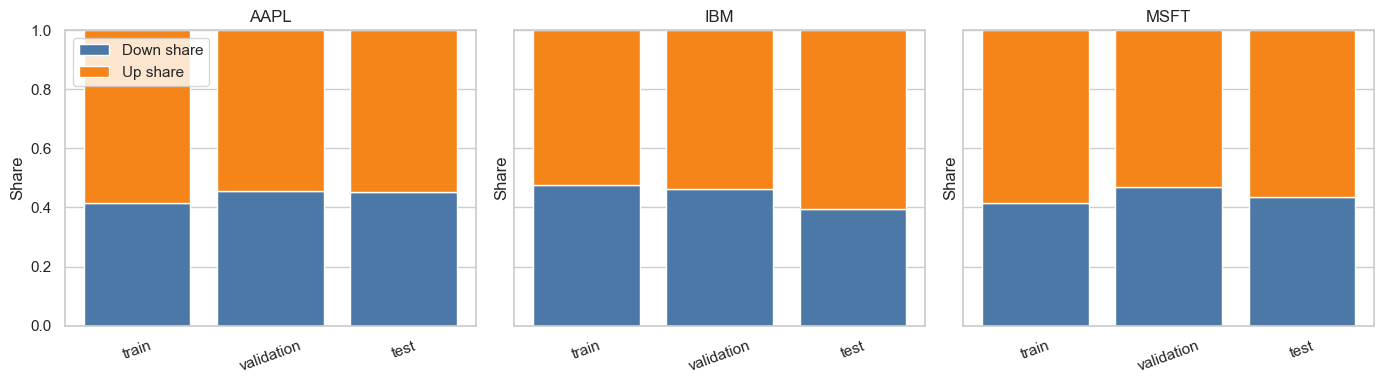

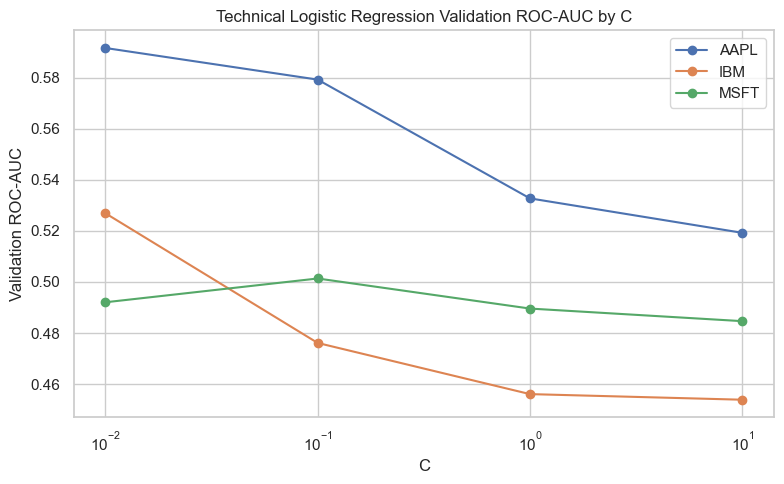

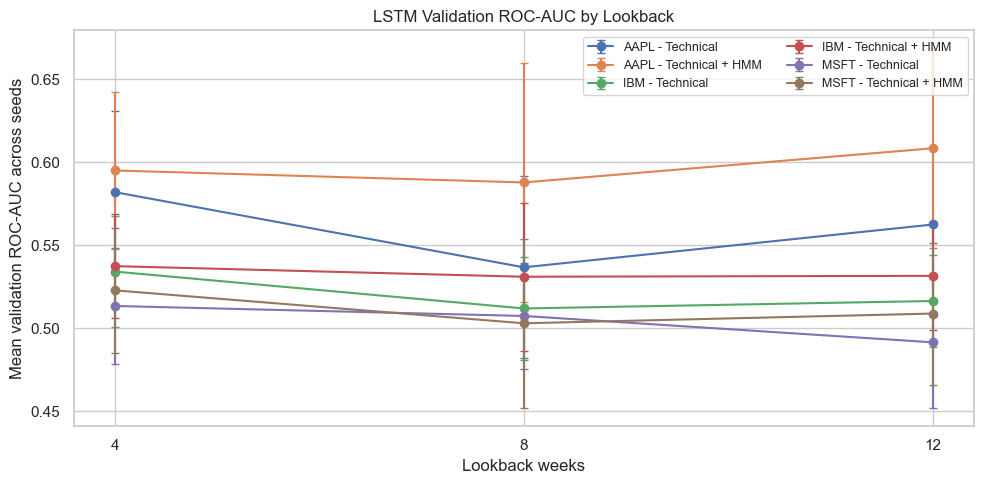

In [15]:
def save_current_figure(path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()


def model_order() -> list[str]:
    return [
        "Train-majority baseline",
        "Persistence baseline",
        "Technical logistic regression",
        "HMM-only probability benchmark",
        "Technical-only LSTM",
        "Technical-plus-HMM LSTM",
    ]


fig, axes = plt.subplots(1, len(EXPECTED_TICKERS), figsize=(14, 4), sharey=True)
split_order = ["train", "validation", "test"]
for ax, ticker in zip(axes, EXPECTED_TICKERS):
    plot_df = class_balance[class_balance["Ticker"] == ticker].set_index("Split").loc[split_order]
    ax.bar(plot_df.index, plot_df["down_share"], label="Down share", color="#4C78A8")
    ax.bar(plot_df.index, plot_df["up_share"], bottom=plot_df["down_share"], label="Up share", color="#F58518")
    ax.set_title(ticker)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Share")
    ax.tick_params(axis="x", rotation=20)
axes[0].legend(loc="upper left")
save_current_figure(FIGURE_DIR / "class_balance_by_ticker_and_split.png")

plt.figure(figsize=(8, 5))
for ticker in EXPECTED_TICKERS:
    plot_df = logistic_validation_selection[logistic_validation_selection["Ticker"] == ticker]
    plt.plot(plot_df["C"], plot_df["Validation_ROC_AUC"], marker="o", label=ticker, color=ticker_colors[ticker])
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Validation ROC-AUC")
plt.title("Technical Logistic Regression Validation ROC-AUC by C")
plt.legend()
save_current_figure(FIGURE_DIR / "logistic_validation_auc_by_C.png")

plt.figure(figsize=(10, 5))
for (ticker, feature_set), group in lstm_validation_lookback_selection.groupby(["Ticker", "Feature_Set"], sort=True):
    group = group.sort_values("Lookback")
    linestyle = "-" if feature_set == "Technical" else "--"
    plt.errorbar(
        group["Lookback"],
        group["Validation_ROC_AUC_Mean"],
        yerr=group["Validation_ROC_AUC_SD"],
        marker="o",
        capsize=3,
        label=f"{ticker} - {feature_set}",
        color=ticker_colors[ticker],
        linestyle=linestyle,
    )
plt.xticks(LOOKBACK_GRID)
plt.xlabel("Lookback weeks")
plt.ylabel("Mean validation ROC-AUC across seeds")
plt.title("LSTM Validation ROC-AUC by Lookback")
plt.legend(ncol=2, fontsize=9)
save_current_figure(FIGURE_DIR / "lstm_validation_auc_by_lookback.png")


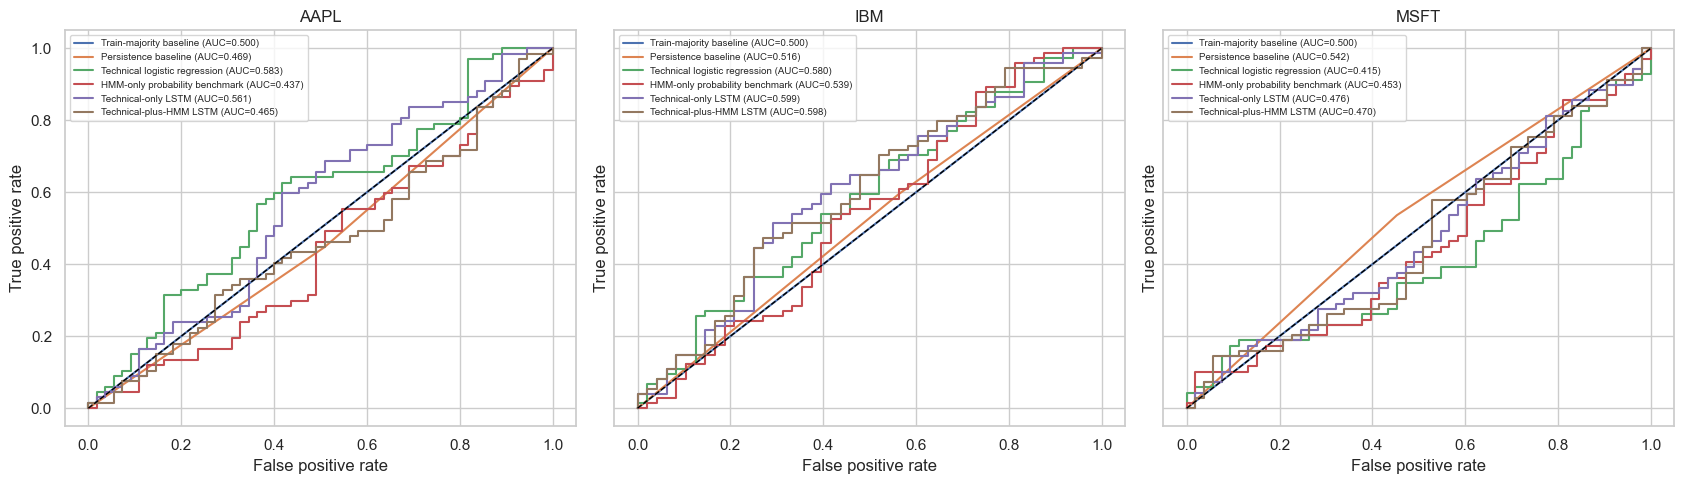

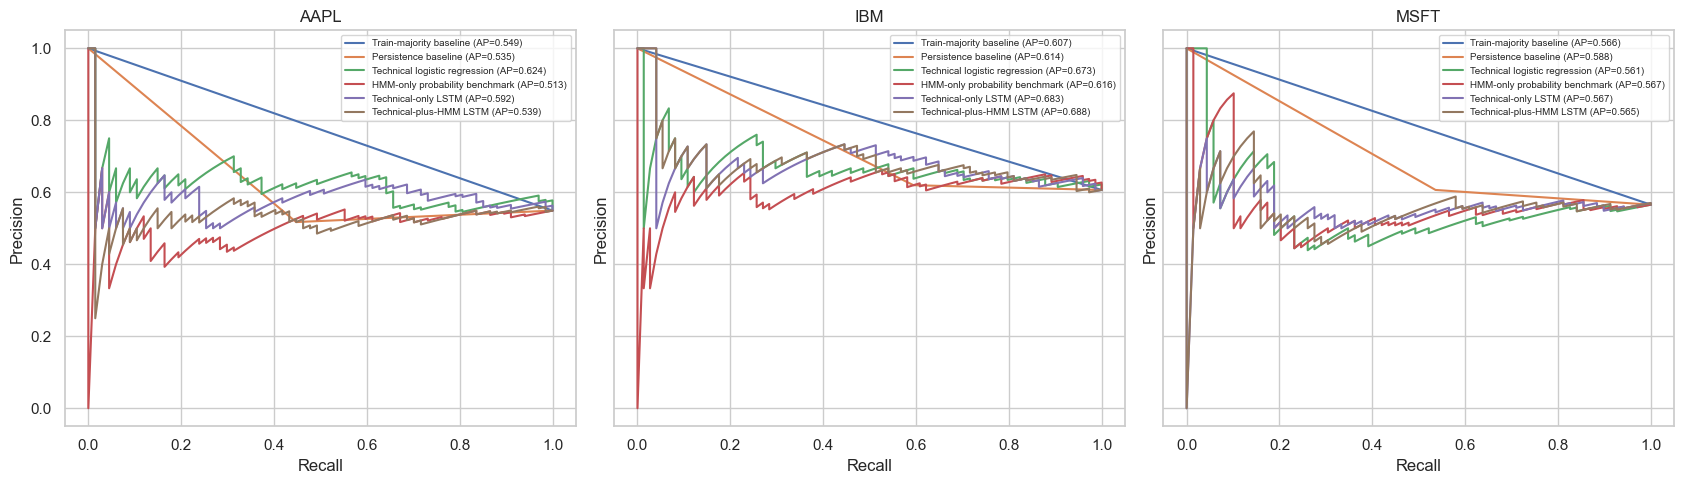

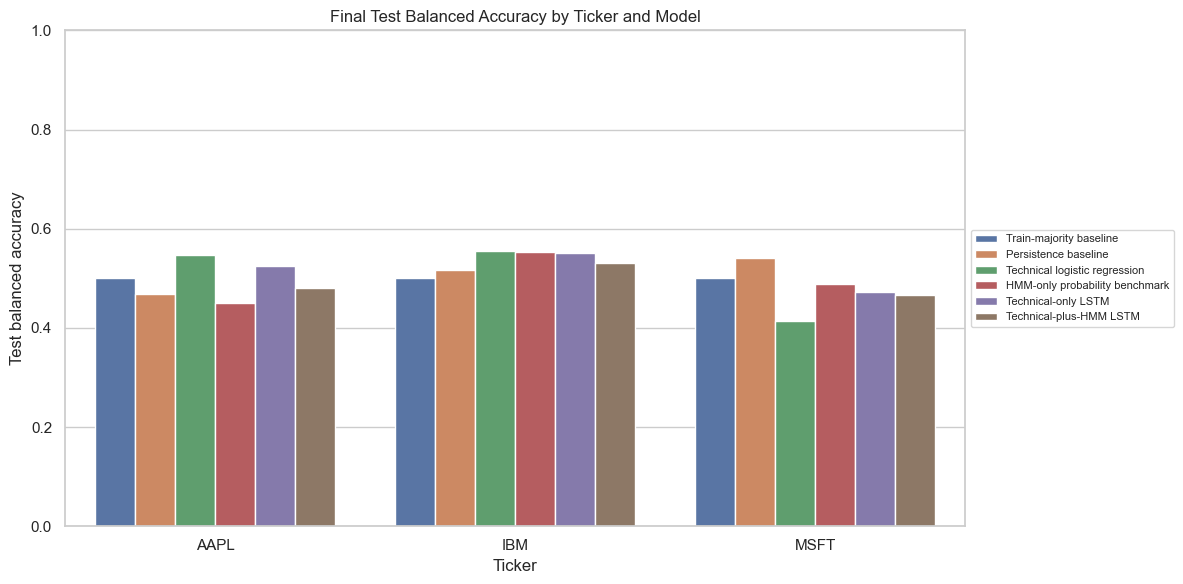

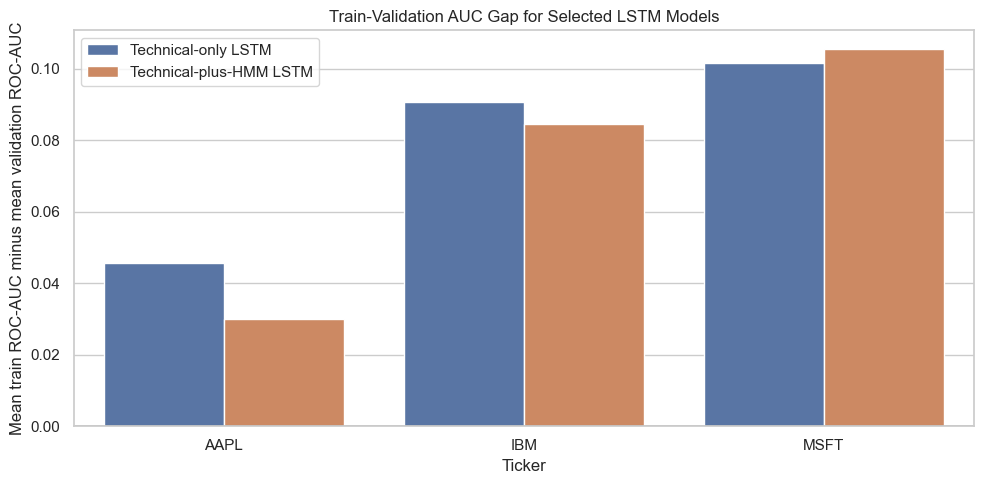

In [16]:
def aggregate_predictions_for_curves(predictions: pd.DataFrame) -> pd.DataFrame:
    """Use one probability series per ticker/model; LSTM probabilities are averaged across selected seeds."""
    deterministic = predictions[predictions["Seed"].isna()].copy()
    lstm = predictions[predictions["Seed"].notna()].copy()
    if lstm.empty:
        return deterministic
    group_cols = ["Ticker", "Model", "Feature_Set", "Date", "Target_Date", "Split"]
    lstm_agg = (
        lstm.groupby(group_cols)
        .agg(
            Selected_Lookback=("Selected_Lookback", "first"),
            Seed=("Seed", lambda values: "mean_across_selected_seeds"),
            Target_State_Binary=("Target_State_Binary", "first"),
            Predicted_Probability_Up=("Predicted_Probability_Up", "mean"),
            Decision_Threshold=("Decision_Threshold", "mean"),
        )
        .reset_index()
    )
    lstm_agg["Predicted_Class"] = (lstm_agg["Predicted_Probability_Up"] >= lstm_agg["Decision_Threshold"]).astype(int)
    return pd.concat([deterministic, lstm_agg], ignore_index=True)


curve_predictions = aggregate_predictions_for_curves(selected_test_predictions)

fig, axes = plt.subplots(1, len(EXPECTED_TICKERS), figsize=(17, 5), sharex=True, sharey=True)
for ax, ticker in zip(axes, EXPECTED_TICKERS):
    ticker_preds = curve_predictions[curve_predictions["Ticker"] == ticker]
    for model_name in model_order():
        model_preds = ticker_preds[ticker_preds["Model"] == model_name]
        if model_preds.empty:
            continue
        y_true = model_preds["Target_State_Binary"].to_numpy(dtype=int)
        y_prob = model_preds["Predicted_Probability_Up"].to_numpy(dtype=float)
        if len(np.unique(y_true)) < 2:
            continue
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc_value = roc_auc_score(y_true, y_prob)
        ax.plot(fpr, tpr, label=f"{model_name} (AUC={auc_value:.3f})")
    ax.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1)
    ax.set_title(ticker)
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.legend(fontsize=7)
save_current_figure(FIGURE_DIR / "final_test_roc_curves_by_ticker.png")

fig, axes = plt.subplots(1, len(EXPECTED_TICKERS), figsize=(17, 5), sharex=True, sharey=True)
for ax, ticker in zip(axes, EXPECTED_TICKERS):
    ticker_preds = curve_predictions[curve_predictions["Ticker"] == ticker]
    for model_name in model_order():
        model_preds = ticker_preds[ticker_preds["Model"] == model_name]
        if model_preds.empty:
            continue
        y_true = model_preds["Target_State_Binary"].to_numpy(dtype=int)
        y_prob = model_preds["Predicted_Probability_Up"].to_numpy(dtype=float)
        if int(np.sum(y_true == 1)) == 0:
            continue
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        ap_value = average_precision_score(y_true, y_prob)
        ax.plot(recall, precision, label=f"{model_name} (AP={ap_value:.3f})")
    ax.set_title(ticker)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend(fontsize=7)
save_current_figure(FIGURE_DIR / "final_test_pr_curves_by_ticker.png")

plt.figure(figsize=(12, 6))
sns.barplot(
    data=controlled_model_summary,
    x="Ticker",
    y="Test_Balanced_Accuracy_Mean",
    hue="Model",
    hue_order=model_order(),
)
plt.ylim(0, 1)
plt.ylabel("Test balanced accuracy")
plt.title("Final Test Balanced Accuracy by Ticker and Model")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)
save_current_figure(FIGURE_DIR / "final_test_balanced_accuracy_comparison.png")

gap_df = (
    lstm_selected_lookback_seed_results.groupby(["Ticker", "Model", "Feature_Set", "Lookback"])
    .agg(
        Train_ROC_AUC_Mean=("Train_ROC_AUC", "mean"),
        Validation_ROC_AUC_Mean=("Validation_ROC_AUC", "mean"),
    )
    .reset_index()
)
gap_df["Train_Validation_AUC_Gap"] = gap_df["Train_ROC_AUC_Mean"] - gap_df["Validation_ROC_AUC_Mean"]
plt.figure(figsize=(10, 5))
sns.barplot(
    data=gap_df,
    x="Ticker",
    y="Train_Validation_AUC_Gap",
    hue="Model",
    hue_order=["Technical-only LSTM", "Technical-plus-HMM LSTM"],
)
plt.axhline(0, color="black", linewidth=1)
plt.ylabel("Mean train ROC-AUC minus mean validation ROC-AUC")
plt.title("Train-Validation AUC Gap for Selected LSTM Models")
plt.legend(loc="best")
save_current_figure(FIGURE_DIR / "train_validation_auc_gap_for_selected_lstm_models.png")


In [17]:
controlled_run_metadata = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "project_root": str(PROJECT_ROOT),
    "inputs": {
        "technical_weekly_scaled": str(TECHNICAL_INPUT_PATH.relative_to(PROJECT_ROOT)),
        "weekly_hmm_features": str(HMM_INPUT_PATH.relative_to(PROJECT_ROOT)),
        "lstm_architecture": str(ARCHITECTURE_PATH.relative_to(PROJECT_ROOT)),
    },
    "outputs_dir": str(OUTPUT_DIR.relative_to(PROJECT_ROOT)),
    "tickers": EXPECTED_TICKERS,
    "target": "Target_State_Binary; next-week up/down direction",
    "hmm_feature_raw": "HMM_Up_Prob_Raw",
    "hmm_feature_scaled": "HMM_Up_Prob_Scaled",
    "technical_features": TECHNICAL_FEATURES,
    "technical_plus_hmm_features": TECHNICAL_PLUS_HMM_FEATURES,
    "lookback_grid": LOOKBACK_GRID,
    "seeds": SEEDS,
    "logistic_C_grid": C_GRID,
    "threshold_grid": THRESHOLD_GRID.tolist(),
    "lstm_config": {
        "lstm_units": list(LSTM_CONFIG.lstm_units),
        "dense_units": list(LSTM_CONFIG.dense_units),
        "dropout": LSTM_CONFIG.dropout,
        "recurrent_dropout": LSTM_CONFIG.recurrent_dropout,
        "learning_rate": LSTM_CONFIG.learning_rate,
        "max_epochs": MAX_EPOCHS,
        "batch_size": BATCH_SIZE,
        "patience": PATIENCE,
        "class_weight": None,
    },
    "upstream_file_state_at_start": UPSTREAM_FILE_STATE,
    "hmm_scaler_fit_metadata": hmm_scaler_fit_metadata.to_dict("records"),
}

with open(OUTPUT_DIR / "controlled_run_metadata.json", "w", encoding="utf-8") as f:
    json.dump(controlled_run_metadata, f, indent=2)

print(f"Saved outputs to: {OUTPUT_DIR}")
print(f"Saved figures to: {FIGURE_DIR}")


Saved outputs to: D:\BA_year_3\honour project\outputs\weekly_controlled_comparison
Saved figures to: D:\BA_year_3\honour project\outputs\weekly_controlled_comparison\figures


# 16. Interpretation Guide and Limitations

The comparison evaluates whether stock-specific HMM-derived information provides incremental out-of-sample value beyond weekly technical indicators. A useful HMM contribution requires consistent improvement over the technical-only LSTM and simple benchmarks across tickers and across random seeds. A result for one ticker or one random seed alone is not sufficient evidence of robust predictive value.

The HMM-implied next-week up probability is an auxiliary latent-state feature. It is not identical to the next-week up/down target.

Limitations: the dataset has a limited number of weekly observations per ticker; weekly next-period direction is intrinsically noisy; results from a single final test block may be unstable; a future extension would use rolling-origin or expanding-window retraining for stricter time-series validation; this notebook does not use QQQ, VIX/VXN, or NBER context because the purpose is a controlled core comparison.


In [18]:
EXPECTED_OUTPUT_FILES = [
    OUTPUT_DIR / "controlled_class_balance.csv",
    OUTPUT_DIR / "controlled_hmm_scaling_diagnostics.csv",
    OUTPUT_DIR / "controlled_sequence_diagnostics.csv",
    OUTPUT_DIR / "logistic_validation_selection.csv",
    OUTPUT_DIR / "lstm_all_runs.csv",
    OUTPUT_DIR / "lstm_validation_lookback_selection.csv",
    OUTPUT_DIR / "lstm_selected_lookback_seed_results.csv",
    OUTPUT_DIR / "controlled_model_results_long.csv",
    OUTPUT_DIR / "controlled_model_summary.csv",
    OUTPUT_DIR / "selected_test_predictions.csv",
    OUTPUT_DIR / "controlled_run_metadata.json",
    FIGURE_DIR / "class_balance_by_ticker_and_split.png",
    FIGURE_DIR / "logistic_validation_auc_by_C.png",
    FIGURE_DIR / "lstm_validation_auc_by_lookback.png",
    FIGURE_DIR / "final_test_roc_curves_by_ticker.png",
    FIGURE_DIR / "final_test_pr_curves_by_ticker.png",
    FIGURE_DIR / "final_test_balanced_accuracy_comparison.png",
    FIGURE_DIR / "train_validation_auc_gap_for_selected_lstm_models.png",
]


def assert_upstream_files_unchanged() -> None:
    changed = []
    for path in UPSTREAM_INPUT_PATHS:
        rel = str(path.relative_to(PROJECT_ROOT))
        current = {"size": path.stat().st_size, "mtime_ns": path.stat().st_mtime_ns}
        if current != UPSTREAM_FILE_STATE[rel]:
            changed.append({"path": rel, "start": UPSTREAM_FILE_STATE[rel], "current": current})
    if changed:
        raise RuntimeError(f"Upstream files changed during this notebook run: {changed}")


assert_upstream_files_unchanged()
all_features_used = TECHNICAL_FEATURES + TECHNICAL_PLUS_HMM_FEATURES
if any(token.lower() in feature.lower() for token in ["QQQ", "VIX", "VXN", "NBER"] for feature in all_features_used):
    raise RuntimeError("A QQQ/VIX/VXN/NBER feature entered a model feature list.")
if "HMM_Bullish_Prob_Next" in all_features_used:
    raise RuntimeError("HMM_Bullish_Prob_Next entered a model feature list.")
if not (hmm_scaler_fit_metadata["Fit_Split"] == "train").all():
    raise RuntimeError("At least one HMM scaler was not fitted using training rows only.")
for name, features in FEATURE_SETS.items():
    validate_feature_list(features, name)

missing_outputs = [str(path.relative_to(PROJECT_ROOT)) for path in EXPECTED_OUTPUT_FILES if not path.exists()]
if missing_outputs:
    raise FileNotFoundError(f"Expected output files are missing: {missing_outputs}")

checklist = [
    "upstream files were not modified",
    "no QQQ/VIX/VXN/NBER features were used",
    "no HMM_Bullish_Prob_Next was used",
    "HMM_Up_Prob_Scaled was fitted using training rows only",
    "no target or future-return columns entered any model feature matrix",
    "all model selection used validation only",
    "no test performance was used to select lookback, C, thresholds, or model structure",
    "all expected output files exist",
]

print("Final sanity checklist:")
for item in checklist:
    print(f"[x] {item}")

print("Controlled weekly HMM-LSTM comparison completed successfully.")


Final sanity checklist:
[x] upstream files were not modified
[x] no QQQ/VIX/VXN/NBER features were used
[x] no HMM_Bullish_Prob_Next was used
[x] HMM_Up_Prob_Scaled was fitted using training rows only
[x] no target or future-return columns entered any model feature matrix
[x] all model selection used validation only
[x] no test performance was used to select lookback, C, thresholds, or model structure
[x] all expected output files exist
Controlled weekly HMM-LSTM comparison completed successfully.
